In [1]:
# Data Handling
import pandas as pd  # Load, clean, transform, and analyze tabular data
import numpy as np   # Numerical operations, arrays, math functions, fast computations

# Visualization
import matplotlib.pyplot as plt   # Core plotting library (line, bar, histogram)
import seaborn as sns             # Statistical plots built on Matplotlib

# Date & Time
from datetime import datetime, timedelta  # Handle dates, timestamps, and time-based calculations

import warnings # Control warning messages
warnings.filterwarnings('ignore')

In [2]:
# Loading and exploring data
path = r"C:\Users\padil\nareshIT\projects\InsightBoard\data\blinkit.csv"
df = pd.read_csv(path)
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [3]:
df.shape

(8523, 12)

In [4]:
df.columns

Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type', 'Item_Outlet_Sales'],
      dtype='object')

In [5]:
df.describe(include="all")

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
count,8523,7060.000000,8523,8523.000000,8523,8523.000000,8523,8523.000000,6113,8523,8523,8523.000000
unique,1559,NaN,5,NaN,16,NaN,10,NaN,3,3,4,NaN
top,FDW13,NaN,Low Fat,NaN,Fruits and Vegetables,NaN,OUT027,NaN,Medium,Tier 3,Supermarket Type1,NaN
freq,10,NaN,5089,NaN,1232,NaN,935,NaN,2793,3350,5577,NaN
mean,NaN,12.857645,NaN,0.066132,NaN,140.992782,NaN,1997.831867,NaN,NaN,NaN,2181.288914
std,NaN,4.643456,NaN,0.051598,NaN,62.275067,NaN,8.371760,NaN,NaN,NaN,1706.499616
min,NaN,4.555000,NaN,0.000000,NaN,31.290000,NaN,1985.000000,NaN,NaN,NaN,33.290000
25%,NaN,8.773750,NaN,0.026989,NaN,93.826500,NaN,1987.000000,NaN,NaN,NaN,834.247400
50%,NaN,12.600000,NaN,0.053931,NaN,143.012800,NaN,1999.000000,NaN,NaN,NaN,1794.331000
75%,NaN,16.850000,NaN,0.094585,NaN,185.643700,NaN,2004.000000,NaN,NaN,NaN,3101.296400


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [7]:
df.isnull().sum()  # checking missing values

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [8]:
# Item_Weight has 1463 missing values, so we fill it using median weight per Item_Type
df['Item_Weight'] = df.groupby('Item_Type')['Item_Weight'].transform(lambda x: x.fillna(x.median()))

In [9]:
# categorical data
# Outlet_Size has 2410 missing values.
# outlet size depends on outlet type.
# so we fill it with mode.

df['Outlet_Size'] = df.groupby('Outlet_Type')['Outlet_Size'].transform(lambda x: x.fillna(x.mode()[0]))

In [10]:
df.isnull().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

In [11]:
df.duplicated()  # checking if data has any duplicate values

0       False
1       False
2       False
3       False
4       False
        ...  
8518    False
8519    False
8520    False
8521    False
8522    False
Length: 8523, dtype: bool

In [14]:
# Normalizing Item_Fat_Content
# Has inconsistent values

df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({
    'LF': 'Low Fat',
    'low fat': 'Low Fat',
    'reg': 'Regular'
})

print("Cleaned Fat Content distribution:")
print(df['Item_Fat_Content'].value_counts())

Cleaned Fat Content distribution:
Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64


**Feature Engineering**

In [15]:
df.dtypes

Item_Identifier               object
Item_Weight                  float64
Item_Fat_Content              object
Item_Visibility              float64
Item_Type                     object
Item_MRP                     float64
Outlet_Identifier             object
Outlet_Establishment_Year      int64
Outlet_Size                   object
Outlet_Location_Type          object
Outlet_Type                   object
Item_Outlet_Sales            float64
dtype: object

In [16]:
CURRENT_YEAR = 2026
df['Outlet_Age'] = CURRENT_YEAR - df['Outlet_Establishment_Year']

In [19]:
df['Outlet_Age_Group'] = pd.cut(
    df['Outlet_Age'],
    bins=[0, 10, 20, 40],
    labels=['New', 'Mid', 'Old']
)

In [20]:
df['MRP_Band'] = pd.cut(
    df['Item_MRP'],
    bins=[0, 70, 140, 210, 300],
    labels=['Low', 'Medium', 'High', 'Premium']
)

In [21]:
df['Low_Visibility'] = (df['Item_Visibility'] < 0.05).astype(int)

In [22]:
df['Sales_Performance'] = pd.qcut(
    df['Item_Outlet_Sales'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

In [23]:
df['Sales_Score'] = pd.qcut(df['Item_Outlet_Sales'], q=5, labels=False)

In [24]:
df['Avg_Item_Sales'] = df.groupby('Item_Identifier')['Item_Outlet_Sales']\
                          .transform('mean')

In [25]:
df['Avg_Outlet_Sales'] = df.groupby('Outlet_Identifier')['Item_Outlet_Sales']\
                            .transform('mean')

In [26]:
total_sales = df['Item_Outlet_Sales'].sum()
df['Sales_Contribution_%'] = (df['Item_Outlet_Sales'] / total_sales) * 100

In [27]:
df['Outlet_Size_Code'] = df['Outlet_Size'].map({
    'Small': 1,
    'Medium': 2,
    'High': 3
})

In [28]:
df.head()
df.describe(include='all')
df[['Outlet_Age', 'MRP_Band', 'Sales_Performance']].sample(5)

,Outlet_Age,MRP_Band,Sales_Performance
6115,39,High,High
8509,28,Premium,Low
7717,22,High,High
1980,24,Premium,High
8026,19,High,Medium


In [29]:
print("=" * 60)
print("KEY BUSINESS METRICS")
print("=" * 60)
print(f"Total Sales Revenue: ${df['Item_Outlet_Sales'].sum():,.2f}")
print(f"Average Item Sales: ${df['Item_Outlet_Sales'].mean():,.2f}")
print(f"Median Item Sales: ${df['Item_Outlet_Sales'].median():,.2f}")
print(f"Total Unique Items: {df['Item_Identifier'].nunique():,}")
print(f"Total Outlets: {df['Outlet_Identifier'].nunique():,}")
print(f"Total Item Types: {df['Item_Type'].nunique()}")
print(f"Average Item Price (MRP): ${df['Item_MRP'].mean():,.2f}")
print(f"Average Outlet Age: {df['Outlet_Age'].mean():.1f} years")
print("=" * 60)

KEY BUSINESS METRICS
Total Sales Revenue: $18,591,125.41
Average Item Sales: $2,181.29
Median Item Sales: $1,794.33
Total Unique Items: 1,559
Total Outlets: 10
Total Item Types: 16
Average Item Price (MRP): $140.99
Average Outlet Age: 28.2 years


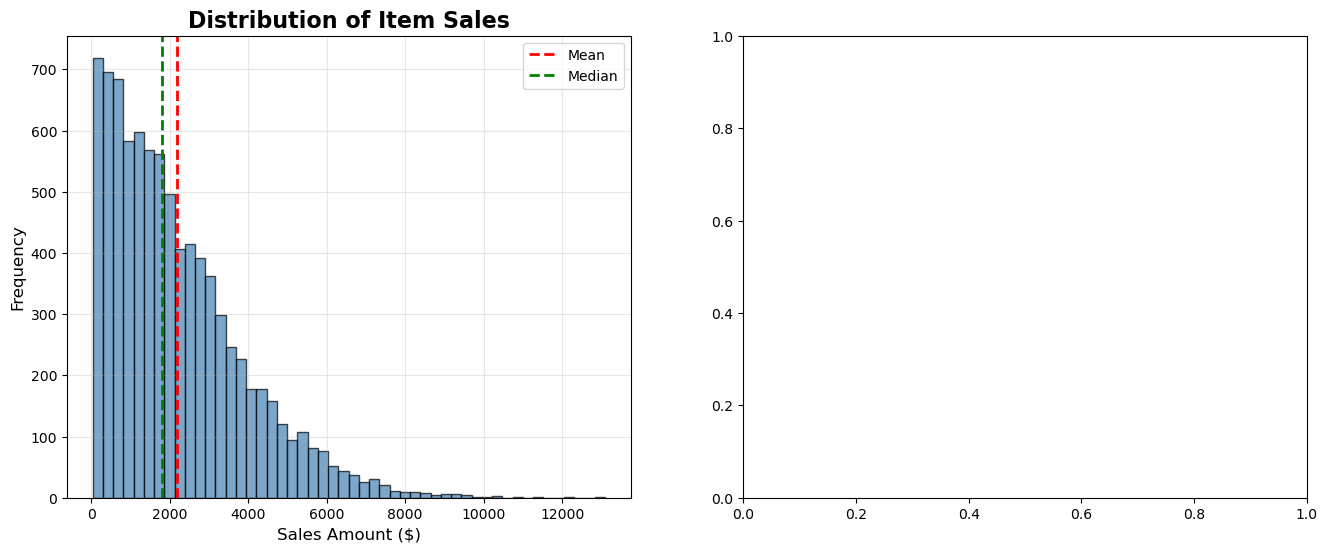

In [30]:
# Sales Distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
axes[0].hist(df['Item_Outlet_Sales'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Item Sales', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Sales Amount ($)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].axvline(df['Item_Outlet_Sales'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[0].axvline(df['Item_Outlet_Sales'].median(), color='green', linestyle='--', linewidth=2, label='Median')
axes[0].legend()
axes[0].grid(alpha=0.3)

In [31]:
# Boxplot

axes[1].boxplot(df['Item_Outlet_Sales'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='blue'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Sales Distribution (Box Plot)', fontsize=16, fontweight='bold')
axes[1].set_ylabel('Sales Amount ($)', fontsize=12)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>


Sales by Outlet Type:
                   Total_Sales  Avg_Sales  Item_Count
Outlet_Type                                          
Supermarket Type1  12917342.26    2316.18        5577
Supermarket Type3   3453926.05    3694.04         935
Supermarket Type2   1851822.83    1995.50         928
Grocery Store        368034.27     339.83        1083


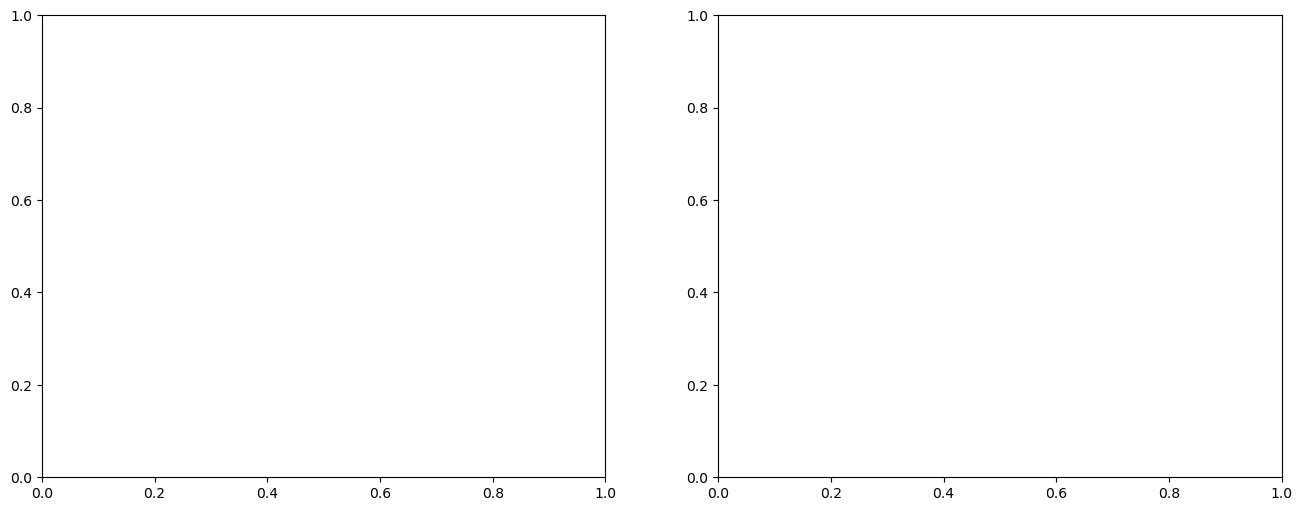

In [32]:
# Sales by Outlet Type

outlet_sales = df.groupby('Outlet_Type').agg({
    'Item_Outlet_Sales': ['sum', 'mean', 'count']
}).round(2)
outlet_sales.columns = ['Total_Sales', 'Avg_Sales', 'Item_Count']
outlet_sales = outlet_sales.sort_values('Total_Sales', ascending=False)

print("\nSales by Outlet Type:")
print(outlet_sales)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))